# HDGMM Tracking with DINO Features

Clean implementation using DINO PCA features as Gaussian-distributed colors.

In [1]:
import os
import json
import time
import jax

# NOTE: Eric, this this chunk below, it will use your compilation cache and speed things up if you restart and need to run the exact same code (assuming no JIT recompilation)
cache_dir = os.path.join(os.getcwd(), ".jax_cache")
if not os.path.exists(cache_dir):
    os.makedirs(cache_dir)
jax.config.update("jax_compilation_cache_dir", cache_dir)
jax.config.update("jax_persistent_cache_min_entry_size_bytes", -1)
jax.config.update("jax_persistent_cache_min_compile_time_secs", 0)
jax.experimental.compilation_cache.compilation_cache.set_cache_dir(cache_dir)

import jax.numpy as jnp
from jax.random import key as jkey

import numpy as np
import pickle
from tqdm import tqdm

from genparticles.datatypes import *
from genparticles.model_3d import *
from genparticles.inference import *
from genparticles.dataloader import *
from genparticles.utils import *
from genparticles.evaluation import *

import genjax
from genjax import Const, gen, Pytree

## Model Definition with DINO Features

In [2]:
# Extended hyperparameters with DINO feature parameters
@Pytree.dataclass
class HDGMM_Hyperparams_DINO(Super_Pytree):
    # Standard hyperparameters
    outlier_prob: jnp.float32 = Super_Pytree.field()
    outlier_velocity_gamma_shape: jnp.float32 = Super_Pytree.field()
    outlier_velocity_gamma_rate: jnp.float32 = Super_Pytree.field()
    alpha: jnp.float32 = Super_Pytree.field()
    beta: jnp.float32 = Super_Pytree.field()
    mu_H: jnp.ndarray = Super_Pytree.field()
    sigma_H: jnp.float32 = Super_Pytree.field()
    nu_H: jnp.float32 = Super_Pytree.field()
    Psi_H: jnp.ndarray = Super_Pytree.field()
    nu_B: jnp.float32 = Super_Pytree.field()
    Psi_B: jnp.ndarray = Super_Pytree.field()
    sigma_V: jnp.float32 = Super_Pytree.field()
    nu_V: jnp.float32 = Super_Pytree.field()
    Psi_V: jnp.ndarray = Super_Pytree.field()
    
    # DINO feature parameters
    mu_F: jnp.ndarray = Super_Pytree.field()  # Mean of DINO features [10] - from PCA
    sigma_F_prior: jnp.ndarray = Super_Pytree.field()  # Std of DINO features [10] - from PCA
    sigma_F: jnp.float32 = Super_Pytree.field()  # Feature variance for datapoints given blob
    
    # Static fields
    translation_max_radius: StaticJnp = Super_Pytree.static()
    translation_num_radii_cells: StaticJnp = Super_Pytree.static()
    translation_theta_step_deg: StaticJnp = Super_Pytree.static()
    translation_gaussian_scale: StaticJnp = Super_Pytree.static()
    rotation_vmf_kappa: StaticJnp = Super_Pytree.static()
    rotation_angle_max_deg: StaticJnp = Super_Pytree.static()
    rotation_angle_step_deg: StaticJnp = Super_Pytree.static()
    n_hyperblobs: jnp.int32 = Super_Pytree.static()
    n_blobs: jnp.int32 = Super_Pytree.static()
    n_datapoints: jnp.int32 = Super_Pytree.static()
    discrete_translation: Precomputed_DiscreteDistribution = Super_Pytree.static()
    discrete_rotation: Precomputed_DiscreteDistribution = Super_Pytree.static()
    
    def __eq__(self, other):
        if jax.tree_util.tree_structure(self) != jax.tree_util.tree_structure(other):
            return False
        leaves1 = jax.tree_util.tree_leaves(self)
        leaves2 = jax.tree_util.tree_leaves(other)
        bools = [jnp.all(l1 == l2) for l1, l2 in zip(leaves1, leaves2)]
        return jnp.all(jnp.array(bools))
    
    @classmethod
    def create(cls, **kwargs):
        return HDGMM_Hyperparams.create.__func__(cls, **kwargs)

# State classes
@Pytree.dataclass
class HDGMM_Blobs_State_DINO(Super_Pytree):
    hyperblob_assignments: jnp.ndarray
    blob_weights: jnp.ndarray
    blob_means: jnp.ndarray
    blob_covs: jnp.ndarray
    blob_vel_means: jnp.ndarray
    blob_vel_covs: jnp.ndarray
    blob_features: jnp.ndarray  # DINO features (N, 10)

@Pytree.dataclass
class HDGMM_Datapoints_State_DINO(Super_Pytree):
    blob_assignments: jnp.ndarray
    datapoint_positions: jnp.ndarray
    datapoint_vels: jnp.ndarray
    datapoint_features: jnp.ndarray  # DINO features (N, 10)

@Pytree.dataclass
class HDGMM_State_DINO(Super_Pytree):
    hypers: HDGMM_Hyperparams_DINO
    hyperblobs_state: HDGMM_Hyperblobs_State
    blobs_state: HDGMM_Blobs_State_DINO
    datapoints_state: HDGMM_Datapoints_State_DINO

In [3]:
# Generative model
@gen
def HDGMM_model_dino(hypers: HDGMM_Hyperparams_DINO):
    hyperblobs_state = HDGMM_hyperblobs_model(hypers) @ 'hyperblobs'
    blobs_state = HDGMM_blobs_model_dino(hypers, hyperblobs_state) @ 'blobs'
    datapoints_state = HDGMM_datapoints_model_dino(hypers, blobs_state) @ 'datapoints'
    
    return HDGMM_State_DINO(
        hypers=hypers,
        hyperblobs_state=hyperblobs_state,
        blobs_state=blobs_state,
        datapoints_state=datapoints_state
    )

@gen
def HDGMM_blobs_model_dino(hypers: HDGMM_Hyperparams_DINO, hyperblobs_state: HDGMM_Hyperblobs_State):
    sample_shape = Const((hypers.n_blobs,))
    
    # Sample blob structure
    hyperblob_assignments = genjax.categorical(
        probs=hyperblobs_state.hyperblob_weights, 
        sample_shape=sample_shape
    ) @ 'hyperblob_assignments'
    
    blob_weights = genjax.dirichlet(jnp.repeat(hypers.beta, hypers.n_blobs)) @ 'blob_weights'
    assigned_hyperblob_per_blob = hyperblobs_state[hyperblob_assignments]
    
    # Spatial parameters
    blob_covs = inverse_wishart(hypers.nu_B, hypers.Psi_B, sample_shape=sample_shape) @ 'blob_covs'
    blob_means = genjax.mv_normal(
        assigned_hyperblob_per_blob.hyperblob_means,
        assigned_hyperblob_per_blob.hyperblob_covs
    ) @ 'blob_means'
    
    # Velocity parameters
    blob_vel_means_ = assigned_hyperblob_per_blob.hyperblob_trans_vels + jnp.einsum(
        'nij,nj->ni',
        assigned_hyperblob_per_blob.hyperblob_rot_vels - jnp.repeat(jnp.eye(3)[None, ...], hypers.n_blobs, axis=0),
        blob_means - assigned_hyperblob_per_blob.hyperblob_means
    )
    blob_vel_means = genjax.normal(blob_vel_means_, jnp.sqrt(hypers.sigma_V)) @ 'blob_vel_means'
    blob_vel_covs = inverse_wishart(hypers.nu_V, hypers.Psi_V, sample_shape=sample_shape) @ 'blob_vel_covs'
    
    # DINO features: Gaussian prior from fitted PCA distribution
    blob_features = genjax.normal(hypers.mu_F, jnp.sqrt(hypers.sigma_F_prior**2)) @ 'blob_features'
    
    return HDGMM_Blobs_State_DINO(
        hyperblob_assignments=hyperblob_assignments,
        blob_weights=blob_weights,
        blob_means=blob_means,
        blob_covs=blob_covs,
        blob_vel_means=blob_vel_means,
        blob_vel_covs=blob_vel_covs,
        blob_features=blob_features,
    )

@gen
def HDGMM_datapoints_model_dino(hypers: HDGMM_Hyperparams_DINO, blobs_state: HDGMM_Blobs_State_DINO):
    blob_assignments = genjax.categorical(
        probs=blobs_state.blob_weights,
        sample_shape=Const((hypers.n_datapoints,))
    ) @ 'blob_assignments'
    
    assigned_blob_per_datapoint = blobs_state[blob_assignments]
    
    # Spatial positions
    datapoint_positions = genjax.mv_normal(
        assigned_blob_per_datapoint.blob_means,
        assigned_blob_per_datapoint.blob_covs
    ) @ 'datapoint_positions'
    
    # Velocities
    datapoint_vels = genjax.mv_normal(
        assigned_blob_per_datapoint.blob_vel_means,
        assigned_blob_per_datapoint.blob_vel_covs
    ) @ 'datapoint_vels'
    
    # DINO features
    datapoint_features = genjax.normal(
        assigned_blob_per_datapoint.blob_features,
        jnp.sqrt(hypers.sigma_F)
    ) @ 'datapoint_features'
    
    return HDGMM_Datapoints_State_DINO(
        blob_assignments=blob_assignments,
        datapoint_positions=datapoint_positions,
        datapoint_vels=datapoint_vels,
        datapoint_features=datapoint_features,
    )

# Likelihood model for inference
@gen
def blob_datapoint_likelihood_model_dino(blob_state: HDGMM_Blobs_State_DINO, sigma_F: jnp.float32):
    datapoint_position = genjax.mv_normal(blob_state.blob_means, blob_state.blob_covs) @ 'datapoint_position'
    datapoint_vel = genjax.mv_normal(blob_state.blob_vel_means, blob_state.blob_vel_covs) @ 'datapoint_vel'
    datapoint_feature = genjax.normal(blob_state.blob_features, jnp.sqrt(sigma_F)) @ 'datapoint_feature'
    return None

# JIT compile
model_jsimulate = jax.jit(HDGMM_model_dino.simulate)
model_jimportance = jax.jit(HDGMM_model_dino.importance)

In [4]:
# DAVIS_3D_MOTION_PATH = "/home/esli/BADJA/DAVIS/davis_3D_motions"
# DAVIS_SEGMASKS_PATH = "/home/esli/BADJA/DAVIS/Annotations/Full-Resolution"

# DAVIS_3D_MOTION_PATH = "/home/esli/GenParticles_neural_stimulus/assets/new_demo_vids/new_demo_vids_3D_motions"
# DAVIS_SEGMASKS_PATH = "/home/esli/GenParticles_neural_stimulus/assets/new_demo_vids/masks"
# DAVIS_RGB_PATH = "/home/esli/GenParticles_neural_stimulus/assets/new_demo_vids/"

VIDEO_NAME = "cloth_bag"  # Change this to any video name (e.g., "elephant", "blackswan", "goat", etc.)

DAVIS_3D_MOTION_PATH = "/home/esli/GenParticles_neural_stimulus/assets/cvpr_deformable_experiment/npzs"
DAVIS_SEGMASKS_PATH = "/home/esli/GenParticles_neural_stimulus/assets/cvpr_deformable_experiment/segmasks"
DAVIS_RGB_PATH = "/home/esli/GenParticles_neural_stimulus/assets/cvpr_deformable_experiment/frames"
DINO_PATH = f'/home/esli/GenParticles_neural_stimulus/assets/cvpr_deformable_experiment/dino_features/dino_features_pca_l/{VIDEO_NAME}_dino_pca_per_pixel.npz'


## Load DINO Features

In [5]:
# Configuration

# Camera intrinsics for projection (DAVIS dataset standard)
# These are used for projecting 3D blob means to 2D pixel coordinates
FOCAL_LENGTH = 520.0  # fx = fy (square pixels)

# Load DINO PCA features
pca_data = np.load(DINO_PATH)
pca_features_unnormalized = pca_data['pca_features_unnormalized']  # [T, h, w, 10]
gaussian_means = pca_data['gaussian_means']  # [10]
gaussian_stds = pca_data['gaussian_stds']  # [10]

print(f"Loaded DINO features for {VIDEO_NAME}: {pca_features_unnormalized.shape}")
print(f"Gaussian parameters:")
for i in range(10):
    print(f"  PC{i+1}: μ={gaussian_means[i]:.4f}, σ={gaussian_stds[i]:.4f}")

Loaded DINO features for cloth_bag: (58, 520, 960, 10)
Gaussian parameters:
  PC1: μ=0.0001, σ=14.1620
  PC2: μ=0.0000, σ=11.9329
  PC3: μ=-0.0000, σ=9.3633
  PC4: μ=0.0000, σ=8.2319
  PC5: μ=0.0000, σ=7.9663
  PC6: μ=0.0000, σ=7.8388
  PC7: μ=0.0000, σ=6.5725
  PC8: μ=0.0000, σ=5.8786
  PC9: μ=0.0000, σ=5.5709
  PC10: μ=-0.0000, σ=5.1887


## Helper Functions

In [6]:
def extract_dino_features(stimulus, pca_features, img_dims, num_timesteps):
    """
    Extract DINO features reshaped to match tracking data.
    Downsamples to match img_dims if necessary.
    
    Returns:
        tracked_features: Array of shape (T, N, 10) where N = img_dims[0] * img_dims[1]
    """
    import cv2
    T, h, w, num_features = pca_features.shape
    target_h, target_w = img_dims
    
    # Check if we need to downsample
    if (h, w) != (target_h, target_w):
        print(f"Downsampling DINO features from {h}x{w} to {target_h}x{target_w}")
        tracked_features = np.zeros((num_timesteps, target_h, target_w, num_features), dtype=pca_features.dtype)
        for t in range(num_timesteps):
            for c in range(num_features):
                tracked_features[t, :, :, c] = cv2.resize(
                    pca_features[t, :, :, c], 
                    (target_w, target_h),
                    interpolation=cv2.INTER_LINEAR
                )
    else:
        tracked_features = pca_features[:num_timesteps]
    
    # Reshape to (T, N, num_features)
    tracked_features = tracked_features.reshape(num_timesteps, -1, num_features)
    return tracked_features

def initialize_model_with_dino(tracked_points, num_blobs, num_hyperblobs, 
                               segmentation_mask, motion_vectors, tracked_features):
    """
    Initialize model with DINO features.
    """
    from genjax import ChoiceMapBuilder as C
    
    # Get standard initialization
    kmeans_chm, roi_blob_indices, roi_hyperblob_indices = make_hierarchical_kmeans_chm_with_mask_fixed_hyperblob(
        tracked_points, num_blobs, num_hyperblobs,
        segmentation_mask=segmentation_mask,
        motion_vectors=motion_vectors
    )
    
    # Add DINO features
    frame_features = tracked_features[0]  # (N, num_features)
    blob_assignments = np.array(kmeans_chm['datapoints', 'blob_assignments'])
    
    # Compute average feature per blob
    num_blobs_actual = len(np.unique(blob_assignments))
    num_features = frame_features.shape[1]
    blob_features = np.zeros((num_blobs_actual, num_features), dtype=np.float32)
    
    for i in range(num_blobs_actual):
        points_in_blob = np.where(blob_assignments == i)[0]
        if len(points_in_blob) > 0:
            blob_features[i] = np.mean(frame_features[points_in_blob], axis=0)
    
    # Add to choice map
    kmeans_chm = kmeans_chm | C['datapoints', 'datapoint_features'].set(a_(frame_features))
    kmeans_chm = kmeans_chm | C['blobs', 'blob_features'].set(a_(blob_features))
    
    return kmeans_chm, roi_blob_indices, roi_hyperblob_indices

In [7]:
## Inference Functions

def gibbs_blob_features_dino(key, hdgmm_state):
    """
    Gibbs update for blob DINO features.
    
    Model:
    - Prior: blob_features ~ N(mu_F, sigma_F_prior^2)  [Gaussian prior from PCA]
    - Likelihood: datapoint_features | blob ~ N(blob_features, sigma_F)
    
    Posterior (conjugate Gaussian-Gaussian):
    - posterior_precision = 1/sigma_F_prior^2 + N_l/sigma_F
    - posterior_mean = (mu_F/sigma_F_prior^2 + sum(datapoint_features)/sigma_F) / posterior_precision
    """
    posterior_key, _ = jax.random.split(key)
    
    # Data
    datapoint_features = hdgmm_state.datapoints_state.datapoint_features  # [N, 10]
    blob_assignments = hdgmm_state.datapoints_state.blob_assignments  # [N]
    
    # Hyperparams
    mu_F = hdgmm_state.hypers.mu_F  # [10]
    sigma_F_prior = hdgmm_state.hypers.sigma_F_prior  # [10]
    sigma_F = hdgmm_state.hypers.sigma_F  # scalar
    L = hdgmm_state.hypers.n_blobs
    
    # Count datapoints per blob
    N_l = jax.ops.segment_sum(jnp.ones(datapoint_features.shape[0]), blob_assignments, num_segments=L)  # [L]
    
    # Sum of features per blob
    S_l = stable_segment_sum(datapoint_features, blob_assignments, L)  # [L, 10]
    
    # Conjugate Gaussian-Gaussian posterior
    # Prior precision (per dimension)
    prior_precision = 1.0 / (sigma_F_prior ** 2)  # [10]
    
    # Likelihood precision (scalar, same for all dimensions)
    likelihood_precision = 1.0 / sigma_F
    
    # Posterior precision (broadcast N_l to [L, 10])
    posterior_precision = prior_precision[None, :] + N_l[:, None] * likelihood_precision  # [L, 10]
    
    # Posterior mean
    # Numerator: prior_mean * prior_precision + data_sum * likelihood_precision
    posterior_mean_numerator = (mu_F[None, :] * prior_precision[None, :] + 
                                S_l * likelihood_precision)  # [L, 10]
    posterior_mean = posterior_mean_numerator / posterior_precision  # [L, 10]
    
    # Posterior std
    posterior_std = 1.0 / jnp.sqrt(posterior_precision)  # [L, 10]
    
    # For blobs with no datapoints, use the prior
    has_points = N_l > 0
    posterior_mean = jnp.where(has_points[:, None], posterior_mean, mu_F[None, :])
    posterior_std = jnp.where(has_points[:, None], posterior_std, sigma_F_prior[None, :])
    
    # Sample new blob features
    new_blob_features = genjax.normal.sample(
        posterior_key,
        posterior_mean,
        posterior_std
    )
    
    return hdgmm_state.replace({'blobs_state': {'blob_features': new_blob_features}})

In [8]:
def gibbs_blob_assignments_dino(key, hdgmm_state, position_only=False, 
                                velocity_only=False, disable_outlier_prob=False, feature_only=False):
    """
    Gibbs update for blob assignments with DINO feature likelihood.
    """
    from genjax import ChoiceMapBuilder as C
    
    posterior_key, _ = jax.random.split(key)
    batch_size = 975
    
    hypers = hdgmm_state.hypers
    num_blobs = hypers.n_blobs
    num_datapoints = hypers.n_datapoints
    datapoint_positions = hdgmm_state.datapoints_state.datapoint_positions
    datapoint_vels = hdgmm_state.datapoints_state.datapoint_vels
    datapoint_features = hdgmm_state.datapoints_state.datapoint_features
    blobs_state = hdgmm_state.blobs_state
    
    # Disable likelihood terms based on flags
    gibbs_blob_vel_covs = jnp.where(
        jnp.logical_or(position_only, feature_only),
        1e14 * blobs_state.blob_vel_covs,
        blobs_state.blob_vel_covs
    )
    gibbs_blob_covs = jnp.where(
        jnp.logical_or(velocity_only, feature_only),
        1e14 * blobs_state.blob_covs,
        blobs_state.blob_covs
    )
    blobs_state = blobs_state.replace({
        'blob_vel_covs': gibbs_blob_vel_covs,
        'blob_covs': gibbs_blob_covs
    })
    
    blob_weights = blobs_state.blob_weights
    outlier_prob = jnp.where(disable_outlier_prob, 0.0, hypers.outlier_prob)
    
    # Normalized mixture weights
    extended_weights = jnp.concatenate([blob_weights, jnp.array([outlier_prob])])
    normalized_weights = extended_weights / jnp.sum(extended_weights)
    log_mixture_weights = jnp.log(normalized_weights)
    
    sigma_F = hypers.sigma_F
    
    def compute_local_density(point_idx):
        chm = (
            C["datapoint_position"].set(datapoint_positions[point_idx]) |
            C["datapoint_vel"].set(datapoint_vels[point_idx]) |
            C["datapoint_feature"].set(datapoint_features[point_idx])
        )
        
        # Real blobs: include feature likelihood
        log_liks = jax.vmap(
            lambda i: blob_datapoint_likelihood_model_dino.assess(chm, (blobs_state[i], sigma_F))[0]
        )(jnp.arange(num_blobs))
        
        # Outlier: Gamma over velocity
        v = datapoint_vels[point_idx]
        speed = jnp.linalg.norm(v)
        alpha = hypers.outlier_velocity_gamma_shape
        beta = hypers.outlier_velocity_gamma_rate
        log_gamma_vel = (
            (alpha - 1) * jnp.log(speed + 1e-8)
            - beta * speed
            - alpha * jnp.log(1. / beta)
            - jax.lax.lgamma(alpha)
        )
        log_gamma_vel = jnp.where(disable_outlier_prob, 0.0, log_gamma_vel)
        
        raw_log_liks = jnp.concatenate([log_liks, jnp.array([log_gamma_vel])])
        return raw_log_liks + log_mixture_weights
    
    # Batched computation
    def batch_compute_logprobs(carry, batch_idx):
        batch_start = batch_idx * batch_size
        batch_indices = jnp.arange(batch_size) + batch_start
        batch_logprobs = jax.vmap(compute_local_density)(batch_indices)
        return carry, batch_logprobs
    
    num_full_batches = num_datapoints // batch_size
    _, batched_logprobs = jax.lax.scan(
        batch_compute_logprobs,
        None,
        jnp.arange(num_full_batches)
    )
    
    all_logprobs = batched_logprobs.reshape(num_full_batches * batch_size, -1)
    updated_assignments = genjax.categorical.sample(posterior_key, logits=all_logprobs)
    
    return hdgmm_state.replace({
        'datapoints_state': {'blob_assignments': updated_assignments}
    })

def blob_tracking_gibbs_dino(key, hdgmm_state):
    """
    Single-frame Gibbs updates.
    """
    def update_blob_assignments_position_only(i, carry):
        key, hdgmm_state = carry
        key, gibbs_key = jax.random.split(key)
        hdgmm_state = gibbs_blob_assignments_dino(
            gibbs_key, hdgmm_state, position_only=True, disable_outlier_prob=True
        )
        key, gibbs_key = jax.random.split(key)
        hdgmm_state = gibbs_blob_weights(gibbs_key, hdgmm_state)
        return key, hdgmm_state
    
    def update_blob_assignments_with_outlier(i, carry):
        key, hdgmm_state = carry
        key, gibbs_key = jax.random.split(key)
        hdgmm_state = gibbs_blob_assignments_dino(
            gibbs_key, hdgmm_state, position_only=True, disable_outlier_prob=False
        )
        key, gibbs_key = jax.random.split(key)
        hdgmm_state = gibbs_blob_weights(gibbs_key, hdgmm_state)
        return key, hdgmm_state
    
    def update_blob_velocities(i, carry):
        key, hdgmm_state = carry
        key, gibbs_key = jax.random.split(key)
        hdgmm_state = gibbs_blob_vel_means(gibbs_key, hdgmm_state)
        return key, hdgmm_state
    
    def update_blob_velocity_covariances(i, carry):
        key, hdgmm_state = carry
        key, gibbs_key = jax.random.split(key)
        hdgmm_state = gibbs_blob_vel_covs(gibbs_key, hdgmm_state)
        return key, hdgmm_state
    
    def update_blob_means(i, carry):
        key, hdgmm_state = carry
        key, gibbs_key = jax.random.split(key)
        hdgmm_state = gibbs_blob_means(gibbs_key, hdgmm_state)
        return key, hdgmm_state
    
    def hyperblob_update_loop(i, carry):
        key, hdgmm_state = carry
        key, gibbs_key = jax.random.split(key)
        hdgmm_state = gibbs_hyperblob_means(gibbs_key, hdgmm_state)
        key, gibbs_key = jax.random.split(key)
        hdgmm_state = gibbs_hyperblob_covs(gibbs_key, hdgmm_state)
        key, gibbs_key = jax.random.split(key)
        hdgmm_state = gibbs_hyperblob_rot(gibbs_key, hdgmm_state)
        key, gibbs_key = jax.random.split(key)
        hdgmm_state = gibbs_hyperblob_trans(gibbs_key, hdgmm_state)
        return key, hdgmm_state
    
    # Gibbs sweep - SIGNIFICANTLY INCREASED LOOP RANGES (the N in fori_loop(0, N, ...))
    key, hdgmm_state = jax.lax.fori_loop(0, 3, hyperblob_update_loop, (key, hdgmm_state))
    key, hdgmm_state = jax.lax.fori_loop(0, 3, update_blob_assignments_position_only, (key, hdgmm_state))
    key, hdgmm_state = jax.lax.fori_loop(0, 15, update_blob_means, (key, hdgmm_state))
    key, hdgmm_state = jax.lax.fori_loop(0, 3, update_blob_assignments_with_outlier, (key, hdgmm_state))
    key, hdgmm_state = jax.lax.fori_loop(0, 15, update_blob_velocities, (key, hdgmm_state))
    key, hdgmm_state = jax.lax.fori_loop(0, 15, update_blob_velocity_covariances, (key, hdgmm_state))
    key, hdgmm_state = jax.lax.fori_loop(0, 3, hyperblob_update_loop, (key, hdgmm_state))
    
    return hdgmm_state

def hdgmm_tracking_gibbs_dino(key, init_hdgmm_state, tracked_points, 
                              tracked_motion_vectors, tracked_features, outlier_prob):
    """
    Track over time with DINO features.
    """
    init_hdgmm_state = init_hdgmm_state.replace({'hypers': {'outlier_prob': f_(outlier_prob)}})
    
    @jax.jit
    def f_tracking_sweep(carry, timestep_idx):
        key, hdgmm_state, tracked_points, tracked_motion_vectors, tracked_features = carry
        
        # Update blob means with velocity
        next_blob_means = hdgmm_state.blobs_state.blob_vel_means + hdgmm_state.blobs_state.blob_means
        hdgmm_state = hdgmm_state.replace({'blobs_state': {'blob_means': next_blob_means}})
        
        # Update datapoint observations
        hdgmm_state = hdgmm_state.replace({
            'datapoints_state': {
                'datapoint_positions': tracked_points[timestep_idx],
                'datapoint_vels': tracked_motion_vectors[timestep_idx],
                'datapoint_features': tracked_features[timestep_idx]
            }
        })
        
        # Gibbs sampling
        key, gibbs_key = jax.random.split(key)
        hdgmm_state = blob_tracking_gibbs_dino(gibbs_key, hdgmm_state)
        
        return (key, hdgmm_state, tracked_points, tracked_motion_vectors, tracked_features), \
               hdgmm_TraceWrapper(force_retval=hdgmm_state)
    
    # FIXED: Changed from len(tracked_points) - 1 to len(tracked_points) to avoid dropping the last frame
    timestep_indices = jnp.arange(1, len(tracked_points))
    _, stacked_hdgmm_wtrs = jax.lax.scan(
        f_tracking_sweep,
        (key, init_hdgmm_state, tracked_points, tracked_motion_vectors, tracked_features),
        timestep_indices,
        unroll=1
    )
    
    return HDGMM_Gibbs_TraceWrapper(
        hdgmm_TraceWrapper(force_retval=init_hdgmm_state),
        stacked_hdgmm_wtrs
    )

## Run Tracking

In [9]:
# Configuration - use VIDEO_NAME from above
STIMULUS = VIDEO_NAME
NUM_BLOBS = 500
NUM_HYPERBLOBS = 9


print(f"Running tracking for {STIMULUS}...")

# Load tracking data
tracked_points, tracked_motion_vectors, num_data_tsteps, img_dims = \
    extract_3d_points_and_motion_vectors_data(DAVIS_3D_MOTION_PATH, STIMULUS)

# Load DINO features
tracked_features = extract_dino_features(STIMULUS, pca_features_unnormalized, img_dims, num_data_tsteps)
print(f"Tracked features shape: {tracked_features.shape}")

# Get segmentation mask
first_frame_seg = get_segmentation_mask(
    STIMULUS, 0, DAVIS_SEGMASKS_PATH, img_dims=img_dims, flatten=True
)

# Initialize
kmeans_chm, roi_blob_indices, roi_hyperblob_indices = initialize_model_with_dino(
    tracked_points, NUM_BLOBS, NUM_HYPERBLOBS,
    first_frame_seg, tracked_motion_vectors, tracked_features
)

# Camera intrinsics for projection (used later for evaluation)
fx = fy = 500.0
cx = img_dims[1] / 2.0  # img_dims = (height, width)
cy = img_dims[0] / 2.0

# Compute empirical hyperparameters
num_datapoints = kmeans_chm['datapoints', 'datapoint_positions'].shape[0]
num_blobs = kmeans_chm['blobs', 'hyperblob_assignments'].shape[0]
num_hyperblobs = kmeans_chm['hyperblobs', 'hyperblob_means'].shape[0]

empirical_mu_H = jnp.median(kmeans_chm['datapoints', 'datapoint_positions'], axis=0)
empirical_sigma_H = (10 * 0.5) ** 2
empirical_Psi_B = jnp.median(kmeans_chm['blobs', 'blob_covs'][roi_blob_indices], axis=0)
empirical_Psi_H = jnp.median(kmeans_chm['hyperblobs', 'hyperblob_covs'][roi_hyperblob_indices], axis=0)
empirical_Psi_V = jnp.median(kmeans_chm['blobs', 'blob_vel_covs'][roi_blob_indices], axis=0)
mean_blobs_per_roi_hyperblob = jnp.sum(
    jnp.isin(kmeans_chm['blobs', 'hyperblob_assignments'], roi_hyperblob_indices)
) / len(roi_hyperblob_indices)
empirical_nu_H = f_(int(mean_blobs_per_roi_hyperblob))
mean_points_per_roi_blob = jnp.sum(
    jnp.isin(kmeans_chm['datapoints', 'blob_assignments'], roi_blob_indices)
) / len(roi_blob_indices)
empirical_nu_B = empirical_nu_V = f_(int(mean_points_per_roi_blob))

# Create hyperparameters
hypers = HDGMM_Hyperparams_DINO.create(
    # DINO feature parameters
    mu_F=jnp.array(gaussian_means),
    sigma_F_prior=jnp.array(gaussian_stds),
    sigma_F=f_(20.0),
    
    # Standard parameters
    outlier_prob=f_(5e0),
    outlier_velocity_gamma_shape=f_(5.0),
    outlier_velocity_gamma_rate=f_(1.0),
    alpha=f_(1.0),
    beta=f_(1.0),
    mu_H=empirical_mu_H,
    sigma_H=empirical_sigma_H,
    nu_H=empirical_nu_H,
    Psi_H=empirical_Psi_H,
    nu_B=empirical_nu_B,
    Psi_B=empirical_Psi_B,
    sigma_V=f_(10e14),
    nu_V=empirical_nu_V,
    Psi_V=empirical_Psi_V,
    translation_gaussian_scale=snp(f_(0.2)),
    translation_max_radius=snp(0.35),
    translation_num_radii_cells=snp(15),
    translation_theta_step_deg=snp(15),
    rotation_vmf_kappa=snp(f_(100)),
    rotation_angle_max_deg=snp(25),
    rotation_angle_step_deg=snp(0.375),
    n_hyperblobs=num_hyperblobs,
    n_blobs=num_blobs,
    n_datapoints=num_datapoints,
)

print("Hyperparameters created with DINO parameters:")
print(f"  mu_F: {hypers.mu_F}")
print(f"  sigma_F_prior: {hypers.sigma_F_prior}")
print(f"  sigma_F: {hypers.sigma_F}")

Running tracking for cloth_bag...


Tracked features shape: (57, 499200, 10)
Hyperparameters created with DINO parameters:
  mu_F: [ 5.9854494e-05  2.0632569e-05 -3.1295553e-05  3.4924865e-06
  8.7515065e-07  1.6050926e-05  1.0462047e-05  2.3111638e-06
  4.9053178e-05 -3.0448260e-05]
  sigma_F_prior: [14.162025  11.932925   9.363319   8.2318735  7.966335   7.838842
  6.5725183  5.8786016  5.5708976  5.1886597]
  sigma_F: 20.0


In [10]:
# Initialize model
key = jkey(np.random.randint(1e9))
key, key_importance = jax.random.split(key)

init_tr, _ = model_jimportance(key_importance, kmeans_chm, (hypers,))
init_hdgmm_state = init_tr.get_retval()

print(f"Initialized model")
print(f"  Blobs: {init_hdgmm_state.blobs_state.blob_features.shape}")
print(f"  Datapoints: {init_hdgmm_state.datapoints_state.datapoint_features.shape}")

Initialized model
  Blobs: (500, 10)
  Datapoints: (499200, 10)


In [11]:
# Initial Gibbs sweeps - custom loop for DINO
key, init_gibbs_key = jax.random.split(key)
print("Running initial Gibbs sweeps...")

def init_gibbs_sweep_dino(key, hdgmm_state, num_sweeps=15):
    """Custom Gibbs sweeps for DINO initialization."""
    
    def gibbs_iteration(carry, i):
        key, hdgmm_state = carry
        
        # Blob assignments (position only)
        key, gibbs_key = jax.random.split(key)
        hdgmm_state = gibbs_blob_assignments_dino(gibbs_key, hdgmm_state, position_only=True, disable_outlier_prob=True)
        
        # Blob weights
        key, gibbs_key = jax.random.split(key)
        hdgmm_state = gibbs_blob_weights(gibbs_key, hdgmm_state)
        
        # Blob means
        key, gibbs_key = jax.random.split(key)
        hdgmm_state = gibbs_blob_means(gibbs_key, hdgmm_state)
        
        # Blob covs
        key, gibbs_key = jax.random.split(key)
        hdgmm_state = gibbs_blob_covs(gibbs_key, hdgmm_state)
        
        # Blob velocities
        key, gibbs_key = jax.random.split(key)
        hdgmm_state = gibbs_blob_vel_means(gibbs_key, hdgmm_state)
        
        key, gibbs_key = jax.random.split(key)
        hdgmm_state = gibbs_blob_vel_covs(gibbs_key, hdgmm_state)
        
        # DINO features
        key, gibbs_key = jax.random.split(key)
        hdgmm_state = gibbs_blob_features_dino(gibbs_key, hdgmm_state)
        
        return (key, hdgmm_state), hdgmm_TraceWrapper(force_retval=hdgmm_state)
    
    (key, final_state), traces = jax.lax.scan(gibbs_iteration, (key, hdgmm_state), jnp.arange(num_sweeps))
    return HDGMM_Gibbs_TraceWrapper(hdgmm_TraceWrapper(force_retval=hdgmm_state), traces)

gibbs_wtrs = init_gibbs_sweep_dino(init_gibbs_key, init_hdgmm_state, num_sweeps=15)
init_hdgmm_state = gibbs_wtrs[-1].retval
print("Initial Gibbs complete")

Running initial Gibbs sweeps...
Initial Gibbs complete


In [12]:
# POST-GIBBS FILTERING: Remove blobs from object hyperblob whose 3D means project outside GT mask
print("\nPost-Gibbs filtering: ensuring blob means project inside GT mask...")

# Get blob structure after Gibbs sweeps
blob_means_after_gibbs = np.array(init_hdgmm_state.blobs_state.blob_means)
hyperblob_assignments_after_gibbs = np.array(init_hdgmm_state.blobs_state.hyperblob_assignments)
n_blobs_after_gibbs = len(blob_means_after_gibbs)

# Project blob means to 2D
x_2d = (blob_means_after_gibbs[:, 0] / (blob_means_after_gibbs[:, 2] + 1e-8)) * fx + cx
y_2d = (blob_means_after_gibbs[:, 1] / (blob_means_after_gibbs[:, 2] + 1e-8)) * fy + cy
x_2d = np.clip(x_2d.astype(int), 0, img_dims[1] - 1)
y_2d = np.clip(y_2d.astype(int), 0, img_dims[0] - 1)

# Convert to flat indices
pixel_indices = y_2d * img_dims[1] + x_2d

# Identify object hyperblob based on GT mask overlap
blob_assignments_frame0 = np.array(init_hdgmm_state.datapoints_state.blob_assignments)
valid_mask = blob_assignments_frame0 < n_blobs_after_gibbs
datapoint_to_hyperblob = np.full(len(blob_assignments_frame0), -1, dtype=int)
datapoint_to_hyperblob[valid_mask] = hyperblob_assignments_after_gibbs[blob_assignments_frame0[valid_mask]]

# Count overlap for each hyperblob
hyperblob_overlaps = {}
for hb_idx in range(NUM_HYPERBLOBS):
    hb_mask = datapoint_to_hyperblob == hb_idx
    overlap = np.sum(hb_mask & (first_frame_seg == 1))
    hyperblob_overlaps[hb_idx] = overlap

object_hyperblob_idx = max(hyperblob_overlaps, key=hyperblob_overlaps.get)
print(f"Object hyperblob identified: {object_hyperblob_idx}")

# Find blobs in object hyperblob whose means project outside mask
blobs_in_object = np.where(hyperblob_assignments_after_gibbs == object_hyperblob_idx)[0]
blobs_to_reassign = []

for blob_idx in blobs_in_object:
    pixel_idx = pixel_indices[blob_idx]
    if pixel_idx >= len(first_frame_seg) or not first_frame_seg[pixel_idx]:
        blobs_to_reassign.append(blob_idx)

print(f"Total blobs in object hyperblob: {len(blobs_in_object)}")
print(f"Blobs whose means project outside GT mask: {len(blobs_to_reassign)}")

# Reassign these blobs to a background hyperblob
if len(blobs_to_reassign) > 0:
    # Find the largest background hyperblob
    background_hyperblobs = [hb for hb in range(NUM_HYPERBLOBS) if hb != object_hyperblob_idx]
    background_blob_counts = {hb: np.sum(hyperblob_assignments_after_gibbs == hb) for hb in background_hyperblobs}
    target_background_hb = max(background_blob_counts, key=background_blob_counts.get)
    
    print(f"Reassigning {len(blobs_to_reassign)} blobs to background hyperblob {target_background_hb}")
    
    # Update hyperblob assignments in the state
    updated_hyperblob_assignments = jnp.array(hyperblob_assignments_after_gibbs)
    for blob_idx in blobs_to_reassign:
        updated_hyperblob_assignments = updated_hyperblob_assignments.at[blob_idx].set(target_background_hb)
    
    # Update init_hdgmm_state with corrected assignments
    init_hdgmm_state = init_hdgmm_state.replace({
        'blobs_state': {'hyperblob_assignments': updated_hyperblob_assignments}
    })
    
    print(f"Updated object hyperblob to have {len(blobs_in_object) - len(blobs_to_reassign)} blobs")
else:
    print("All object hyperblob blobs have means projecting inside GT mask!")

print("Post-Gibbs filtering complete")


Post-Gibbs filtering: ensuring blob means project inside GT mask...
Object hyperblob identified: 0
Total blobs in object hyperblob: 143
Blobs whose means project outside GT mask: 0
All object hyperblob blobs have means projecting inside GT mask!
Post-Gibbs filtering complete


In [13]:
# Track over time
key, tracking_key = jax.random.split(key)
tracking_outlier_prob = 1e-40 # 1e-29

print("Running tracking...")
tracking_wtrs = hdgmm_tracking_gibbs_dino(
    tracking_key, init_hdgmm_state,
    tracked_points, tracked_motion_vectors, tracked_features,
    outlier_prob=tracking_outlier_prob
)
print(f"Tracking complete: {len(tracking_wtrs)} frames")

Running tracking...
Tracking complete: 57 frames


In [14]:
# Extract results
tracking_data = []
for frame_idx in range(len(tracking_wtrs)):
    frame = tracking_wtrs[frame_idx]
    frame_data = {
        'n_blobs': frame.retval.hypers.n_blobs,
        'n_hyperblobs': frame.retval.hypers.n_hyperblobs,
        'n_datapoints': frame.retval.hypers.n_datapoints,
        'blob_assignments': np.array(frame.retval.datapoints_state.blob_assignments),
        'datapoint_positions': np.array(frame.retval.datapoints_state.datapoint_positions),
        'datapoint_vels': np.array(frame.retval.datapoints_state.datapoint_vels),
        'datapoint_features': np.array(frame.retval.datapoints_state.datapoint_features),
        'blob_weights': np.array(frame.retval.blobs_state.blob_weights),
        'blob_means': np.array(frame.retval.blobs_state.blob_means),
        'blob_covs': np.array(frame.retval.blobs_state.blob_covs),
        'blob_vel_means': np.array(frame.retval.blobs_state.blob_vel_means),
        'blob_vel_covs': np.array(frame.retval.blobs_state.blob_vel_covs),
        'blob_features': np.array(frame.retval.blobs_state.blob_features),
        'hyperblob_assignments': np.array(frame.retval.blobs_state.hyperblob_assignments),
        'hyperblob_weights': np.array(frame.retval.hyperblobs_state.hyperblob_weights),
        'hyperblob_means': np.array(frame.retval.hyperblobs_state.hyperblob_means),
        'hyperblob_trans_vels': np.array(frame.retval.hyperblobs_state.hyperblob_trans_vels),
        'hyperblob_rot_vels': np.array(frame.retval.hyperblobs_state.hyperblob_rot_vels),
    }
    tracking_data.append(frame_data)

print(f"Extracted tracking data for {len(tracking_data)} frames")

# Store results in the format expected by evaluation code
all_results = {VIDEO_NAME: [tracking_data]}
print(f"Stored results for {VIDEO_NAME}")

Extracted tracking data for 57 frames
Stored results for cloth_bag


In [15]:
# run this new eval code

scene_to_run = VIDEO_NAME # by default

experiment_metrics, best_visualization_data = evaluate_single_davis_video(
    davis_name = scene_to_run,
    multiple_genparticles_list = all_results[scene_to_run],
    annotations_path = DAVIS_SEGMASKS_PATH,
    counting_threshold=100,
    img_dims = img_dims,
    fps_list=None,
    render_results_video=True,
    experiment_save_dir=None
)


📊 Processing dataset: cloth_bag

📈 Trial Results for cloth_bag:
Trial    Recall (%)   Precision  FPR      IoU      AUC ROC 
--------------------------------------------------------------
1        98.02        0.912      0.034    0.895    0.052   
--------------------------------------------------------------
Mean     98.02        0.912      0.034    0.895    0.052   

🎬 Creating results video (with particle overlay)...


In [16]:
# edit the experiment_save_dir path to what you want

# this might take a while

# if you dont want to save to disk, set experiment_save_dir = None, it should render here

create_genmatter_results_video(best_visualization_data, annotations_path = DAVIS_SEGMASKS_PATH, img_dims = img_dims, experiment_save_dir = '.')

💾 Saving visualization to: ./cloth_bag_results_video.mp4
✅ Visualization complete!


## Visualizations

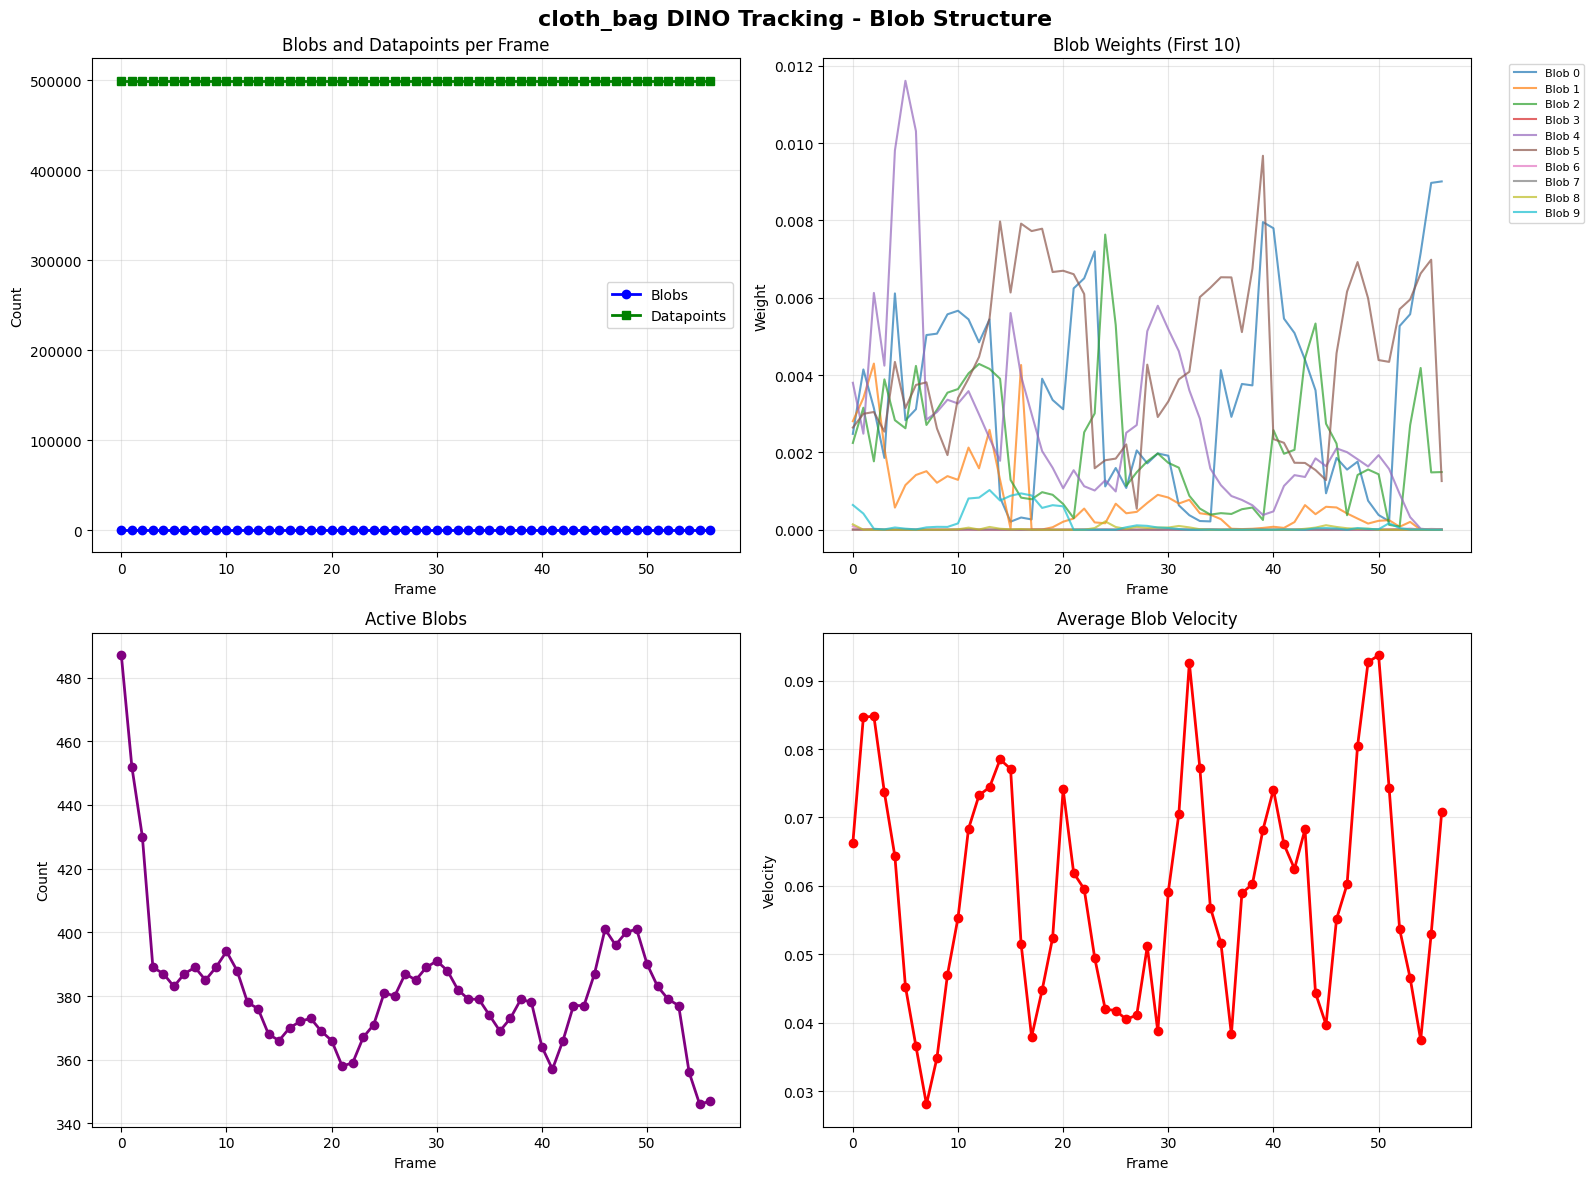

In [17]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

num_frames = len(tracking_data)

# ===== 1. BLOB STRUCTURE OVER TIME =====
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'{VIDEO_NAME} DINO Tracking - Blob Structure', fontsize=16, fontweight='bold')

# 1a. Number of blobs and datapoints
num_blobs_list = [frame['n_blobs'] for frame in tracking_data]
num_datapoints_list = [frame['n_datapoints'] for frame in tracking_data]
axes[0, 0].plot(range(num_frames), num_blobs_list, marker='o', linewidth=2, color='blue', label='Blobs')
axes[0, 0].plot(range(num_frames), num_datapoints_list, marker='s', linewidth=2, color='green', label='Datapoints')
axes[0, 0].set_xlabel('Frame')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Blobs and Datapoints per Frame')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 1b. Blob weights (first 10)
for blob_idx in range(min(10, tracking_data[0]['n_blobs'])):
    weights = [frame['blob_weights'][blob_idx] if blob_idx < len(frame['blob_weights']) else 0 
               for frame in tracking_data]
    axes[0, 1].plot(range(num_frames), weights, linewidth=1.5, alpha=0.7, label=f'Blob {blob_idx}')
axes[0, 1].set_xlabel('Frame')
axes[0, 1].set_ylabel('Weight')
axes[0, 1].set_title('Blob Weights (First 10)')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

# 1c. Active blobs
active_blobs = [len(np.unique(frame['blob_assignments'])) for frame in tracking_data]
axes[1, 0].plot(range(num_frames), active_blobs, marker='o', linewidth=2, color='purple')
axes[1, 0].set_xlabel('Frame')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Active Blobs')
axes[1, 0].grid(True, alpha=0.3)

# 1d. Average velocity
avg_vels = [np.mean(np.linalg.norm(frame['blob_vel_means'], axis=1)) for frame in tracking_data]
axes[1, 1].plot(range(num_frames), avg_vels, marker='o', linewidth=2, color='red')
axes[1, 1].set_xlabel('Frame')
axes[1, 1].set_ylabel('Velocity')
axes[1, 1].set_title('Average Blob Velocity')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

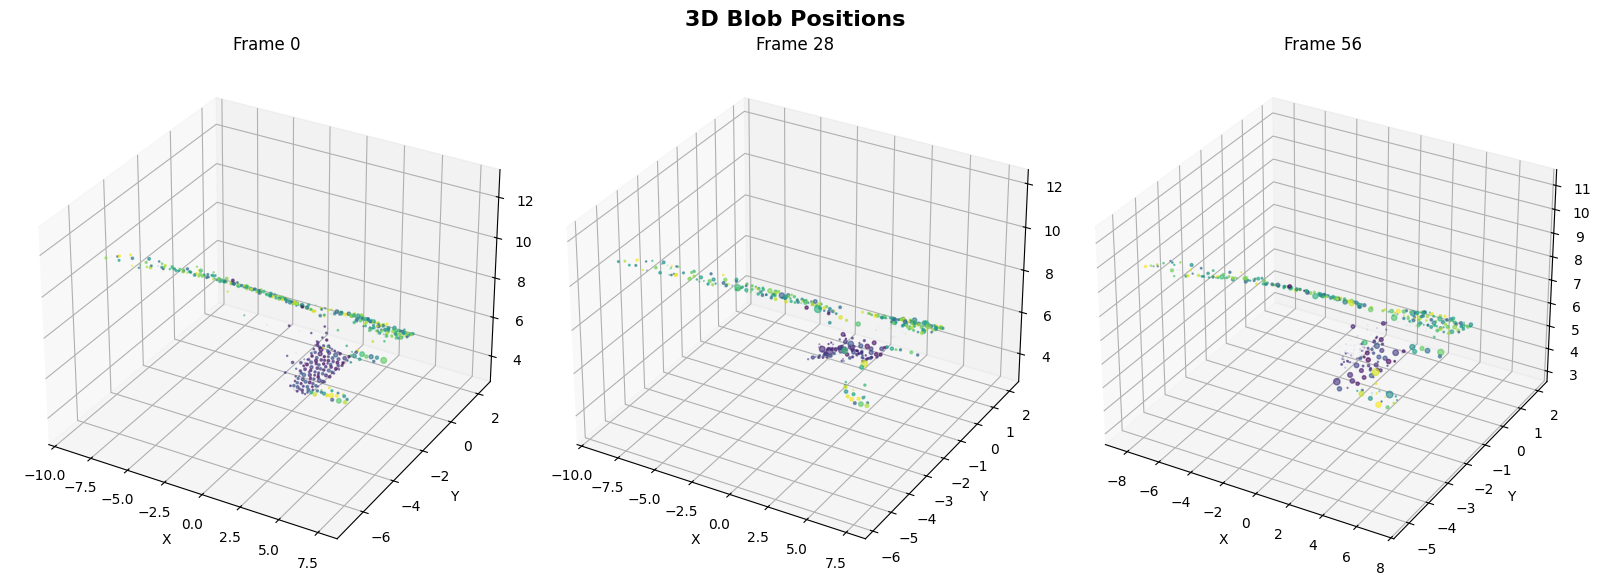

In [18]:
# ===== 2. 3D BLOB POSITIONS =====
fig = plt.figure(figsize=(16, 6))
fig.suptitle('3D Blob Positions', fontsize=16, fontweight='bold')

frames_to_show = [0, num_frames // 2, num_frames - 1]

for i, frame_idx in enumerate(frames_to_show):
    ax = fig.add_subplot(1, 3, i + 1, projection='3d')
    blob_means = tracking_data[frame_idx]['blob_means']
    blob_weights = tracking_data[frame_idx]['blob_weights']
    sizes = blob_weights * 1000
    ax.scatter(blob_means[:, 0], blob_means[:, 1], blob_means[:, 2], 
               c=range(len(blob_means)), s=sizes, alpha=0.6, cmap='viridis')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(f'Frame {frame_idx}')

plt.tight_layout()
plt.show()

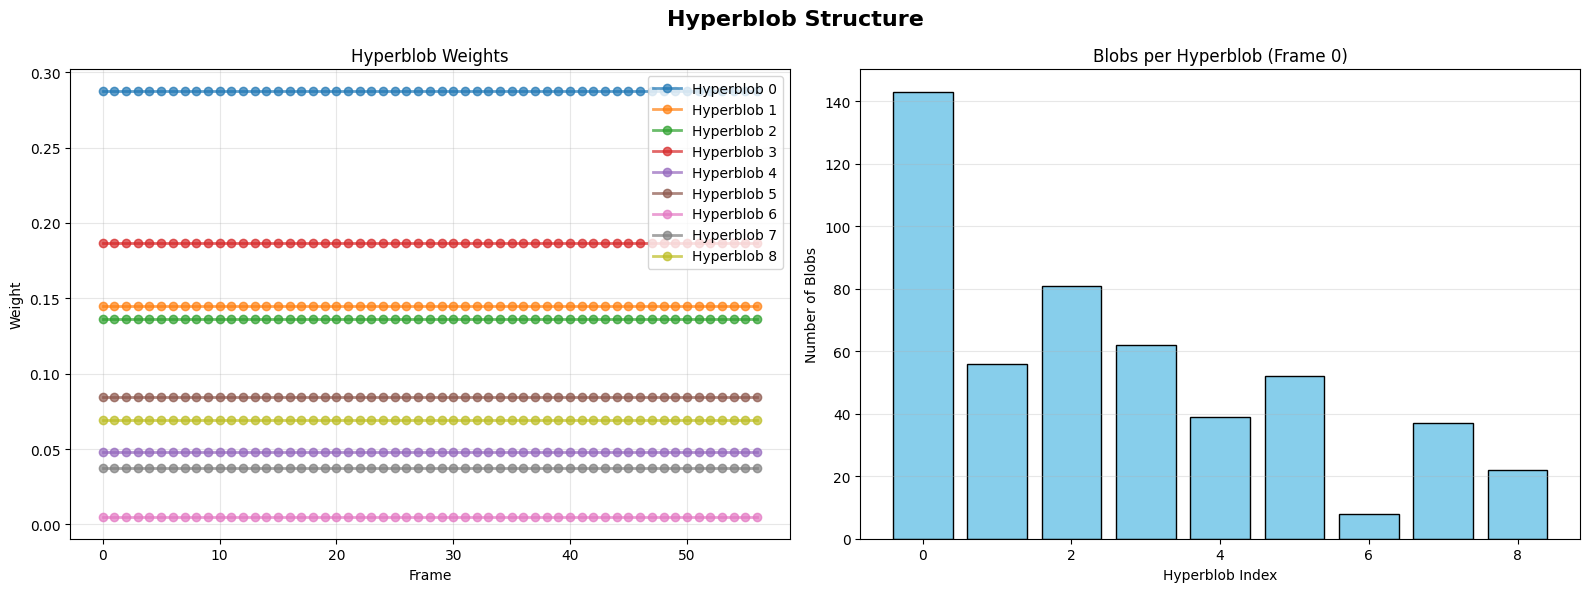

In [19]:
# ===== 3. HYPERBLOB STRUCTURE =====
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Hyperblob Structure', fontsize=16, fontweight='bold')

# Hyperblob weights over time
for hyperblob_idx in range(tracking_data[0]['n_hyperblobs']):
    weights = [frame['hyperblob_weights'][hyperblob_idx] for frame in tracking_data]
    axes[0].plot(range(num_frames), weights, linewidth=2, alpha=0.7, 
                 marker='o', label=f'Hyperblob {hyperblob_idx}')
axes[0].set_xlabel('Frame')
axes[0].set_ylabel('Weight')
axes[0].set_title('Hyperblob Weights')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Blobs per hyperblob (first frame)
hyperblob_assignments = tracking_data[0]['hyperblob_assignments']
unique, counts = np.unique(hyperblob_assignments, return_counts=True)
axes[1].bar(unique, counts, color='skyblue', edgecolor='black')
axes[1].set_xlabel('Hyperblob Index')
axes[1].set_ylabel('Number of Blobs')
axes[1].set_title('Blobs per Hyperblob (Frame 0)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Image dimensions: 520x960


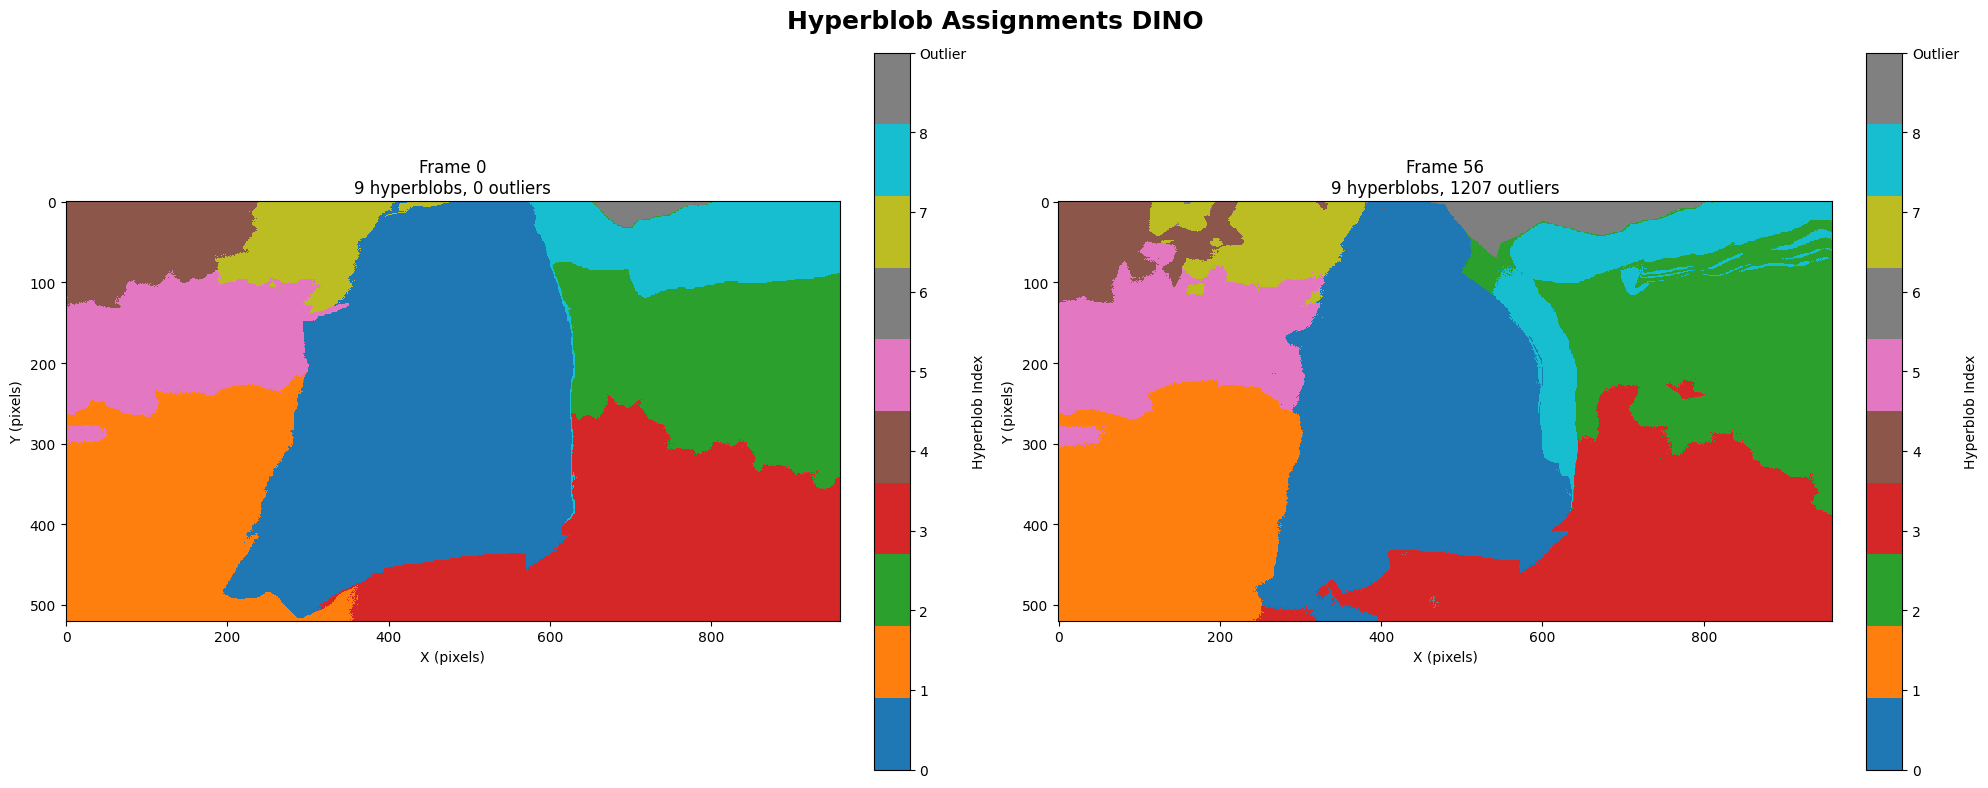

In [20]:
# ===== 4. 2D HYPERBLOB ASSIGNMENT IMAGES =====
# Infer image dimensions
n_datapoints = tracking_data[0]['n_datapoints']
if n_datapoints == 499200:
    img_height, img_width = 520, 960
else:
    import math
    sqrt_n = int(math.sqrt(n_datapoints))
    for h in range(sqrt_n, sqrt_n + 1000):
        if n_datapoints % h == 0:
            w = n_datapoints // h
            if abs(w / h - 1.85) < 0.1:
                img_height, img_width = h, w
                break
    else:
        img_height = img_width = sqrt_n

print(f"Image dimensions: {img_height}x{img_width}")

# Show first and last frames
frames_to_show = [0, num_frames - 1]
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Hyperblob Assignments DINO', fontsize=18, fontweight='bold')

n_hyperblobs = tracking_data[0]['n_hyperblobs']
colors = plt.cm.tab10(np.linspace(0, 1, n_hyperblobs))
colors = np.vstack([colors, [[0.5, 0.5, 0.5, 1.0]]])  # Gray for outliers
cmap = ListedColormap(colors)

for idx, frame_idx in enumerate(frames_to_show):
    frame = tracking_data[frame_idx]
    blob_assignments = frame['blob_assignments']
    hyperblob_assignments = frame['hyperblob_assignments']
    
    # Map datapoints to hyperblobs
    n_blobs = len(hyperblob_assignments)
    valid_mask = blob_assignments < n_blobs
    datapoint_hyperblob_assignments = np.full(len(blob_assignments), n_hyperblobs, dtype=int)
    datapoint_hyperblob_assignments[valid_mask] = hyperblob_assignments[blob_assignments[valid_mask]]
    
    # Reshape to image
    assignment_image = datapoint_hyperblob_assignments.reshape(img_height, img_width)
    n_outliers = np.sum(~valid_mask)
    
    im = axes[idx].imshow(assignment_image, cmap=cmap, vmin=0, vmax=n_hyperblobs, interpolation='nearest')
    axes[idx].set_title(f'Frame {frame_idx}\n{n_hyperblobs} hyperblobs, {n_outliers} outliers')
    axes[idx].set_xlabel('X (pixels)')
    axes[idx].set_ylabel('Y (pixels)')
    
    cbar = plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)
    cbar.set_label('Hyperblob Index')
    cbar.set_ticks(list(range(n_hyperblobs)) + [n_hyperblobs])
    cbar.set_ticklabels(list(range(n_hyperblobs)) + ['Outlier'])

plt.tight_layout()
plt.show()

In [21]:
# ===== 5. SUMMARY STATISTICS =====
print(f"{'='*60}")
print(f"TRACKING SUMMARY FOR {VIDEO_NAME.upper()}")
print(f"{'='*60}")
print(f"Total Frames: {num_frames}")
print(f"Average Number of Blobs: {np.mean(num_blobs_list):.1f}")
print(f"Number of Hyperblobs: {tracking_data[0]['n_hyperblobs']}")
print(f"Number of Datapoints: {tracking_data[0]['n_datapoints']}")
print(f"Average Datapoint Velocity: {np.mean([np.mean(np.linalg.norm(f['datapoint_vels'], axis=1)) for f in tracking_data]):.3f}")
print(f"Average Blob Velocity: {np.mean(avg_vels):.3f}")
print(f"\nDINO Feature Statistics:")
all_blob_features = np.concatenate([f['blob_features'] for f in tracking_data], axis=0)
for i in range(3):
    print(f"  PC{i+1}: mean={all_blob_features[:, i].mean():.4f}, std={all_blob_features[:, i].std():.4f}")
print(f"{'='*60}")

TRACKING SUMMARY FOR CLOTH_BAG
Total Frames: 57
Average Number of Blobs: 500.0
Number of Hyperblobs: 9
Number of Datapoints: 499200
Average Datapoint Velocity: 0.078
Average Blob Velocity: 0.059

DINO Feature Statistics:
  PC1: mean=0.2135, std=13.4335
  PC2: mean=0.6650, std=11.5005
  PC3: mean=2.5308, std=9.3667


## Create Binary Segmentation Video

In [22]:
# Create binary segmentation video from tracking results
# Use the hyperblob that corresponds to the ground truth segmentation from frame 0

import imageio
from tqdm import tqdm

# Find which hyperblob corresponds to the ground truth segmentation mask
print("Finding hyperblob that matches ground truth segmentation...")
frame0 = tracking_data[0]
blob_assignments = frame0['blob_assignments']
hyperblob_assignments = frame0['hyperblob_assignments']
n_blobs = frame0['n_blobs']

# Map datapoints to hyperblobs for frame 0
# NOTE: Outliers (blob_assignments >= n_blobs) are assigned -1
valid_mask = blob_assignments < n_blobs
datapoint_hyperblob_assignments = np.full(len(blob_assignments), -1, dtype=int)
datapoint_hyperblob_assignments[valid_mask] = hyperblob_assignments[blob_assignments[valid_mask]]

# Ensure first_frame_seg is flattened and matches the number of datapoints
if len(first_frame_seg.shape) > 1:
    first_frame_seg_flat = first_frame_seg.flatten()
else:
    first_frame_seg_flat = first_frame_seg

# Verify dimensions match
assert len(first_frame_seg_flat) == len(blob_assignments), \
    f"Segmentation mask size {len(first_frame_seg_flat)} doesn't match datapoints {len(blob_assignments)}"

# Count overlap with ground truth segmentation mask
# first_frame_seg is 1 for foreground, 0 for background
hyperblob_overlaps = {}
for hb_idx in range(frame0['n_hyperblobs']):
    hb_mask = datapoint_hyperblob_assignments == hb_idx
    overlap_with_gt = np.sum(hb_mask & (first_frame_seg_flat == 1))
    hyperblob_overlaps[hb_idx] = overlap_with_gt

# Count outliers (assigned to -1)
n_outliers_frame0 = np.sum(datapoint_hyperblob_assignments == -1)

# Select hyperblob with maximum overlap
HYPERBLOB_TO_SEGMENT = 0 # max(hyperblob_overlaps, key=hyperblob_overlaps.get)

print(f"Hyperblob overlaps with ground truth (frame 0):")
for hb in sorted(hyperblob_overlaps.keys()):
    print(f"  Hyperblob {hb}: {hyperblob_overlaps[hb]} pixels")
print(f"  Outliers: {n_outliers_frame0} pixels")
print(f"\nSelected hyperblob {HYPERBLOB_TO_SEGMENT} (best match to ground truth)")

# Configuration
output_path = f"{VIDEO_NAME}_hyperblob_{HYPERBLOB_TO_SEGMENT}_segmentation.mp4"

# Get dimensions
n_datapoints = tracking_data[0]['n_datapoints']
img_height, img_width = 520, 960  # Standard DAVIS resolution

print(f"\nCreating binary segmentation video for hyperblob {HYPERBLOB_TO_SEGMENT}...")
print(f"Resolution: {img_width}x{img_height}")

# Collect frames
frames = []

# Process each frame
for frame_idx in tqdm(range(len(tracking_data)), desc="Rendering frames"):
    frame = tracking_data[frame_idx]
    blob_assignments = frame['blob_assignments']
    hyperblob_assignments = frame['hyperblob_assignments']
    n_blobs = frame['n_blobs']
    
    # Map datapoints to hyperblobs
    # NOTE: Outliers (blob_assignments >= n_blobs) are assigned -1
    valid_mask = blob_assignments < n_blobs
    datapoint_hyperblob_assignments = np.full(len(blob_assignments), -1, dtype=int)
    datapoint_hyperblob_assignments[valid_mask] = hyperblob_assignments[blob_assignments[valid_mask]]
    
    # Create binary mask: hyperblob HYPERBLOB_TO_SEGMENT -> 255 (white), everything else -> 0 (black)
    # NOTE: Outliers (value -1) are treated as background (value 0)
    binary_mask = np.where(datapoint_hyperblob_assignments == HYPERBLOB_TO_SEGMENT, 255, 0).astype(np.uint8)
    
    # Reshape to image
    binary_image = binary_mask.reshape(img_height, img_width)
    
    # Convert grayscale to RGB (imageio expects RGB)
    binary_rgb = np.stack([binary_image, binary_image, binary_image], axis=-1)
    
    frames.append(binary_rgb)

# Write video using imageio
print(f"Writing video with {len(frames)} frames...")
imageio.mimsave(output_path, frames, fps=30, codec='libx264', quality=8)

print(f"\nBinary segmentation video saved to: {output_path}")
print(f"Total frames: {len(frames)}")
print(f"FPS: 30.0")

# Show statistics (including outliers)
total_pixels = img_height * img_width
hyperblob_pixels_per_frame = []
outlier_pixels_per_frame = []
for frame in tracking_data:
    valid_mask = frame['blob_assignments'] < frame['n_blobs']
    valid_blob_assignments = frame['blob_assignments'][valid_mask]
    hyperblob_mask = frame['hyperblob_assignments'][valid_blob_assignments] == HYPERBLOB_TO_SEGMENT
    hyperblob_pixels_per_frame.append(np.sum(hyperblob_mask))
    outlier_pixels_per_frame.append(np.sum(~valid_mask))

avg_hyperblob_pixels = np.mean(hyperblob_pixels_per_frame)
avg_outlier_pixels = np.mean(outlier_pixels_per_frame)
avg_background = total_pixels - avg_hyperblob_pixels - avg_outlier_pixels

print(f"\nHyperblob {HYPERBLOB_TO_SEGMENT} statistics:")
print(f"  Average foreground pixels: {avg_hyperblob_pixels:.0f} ({100*avg_hyperblob_pixels/total_pixels:.1f}%)")
print(f"  Average outlier pixels: {avg_outlier_pixels:.0f} ({100*avg_outlier_pixels/total_pixels:.1f}%)")
print(f"  Average background pixels: {avg_background:.0f} ({100*avg_background/total_pixels:.1f}%)")

Finding hyperblob that matches ground truth segmentation...
Hyperblob overlaps with ground truth (frame 0):
  Hyperblob 0: 143434 pixels
  Hyperblob 1: 38 pixels
  Hyperblob 2: 0 pixels
  Hyperblob 3: 97 pixels
  Hyperblob 4: 0 pixels
  Hyperblob 5: 14 pixels
  Hyperblob 6: 0 pixels
  Hyperblob 7: 17 pixels
  Hyperblob 8: 19 pixels
  Outliers: 0 pixels

Selected hyperblob 0 (best match to ground truth)

Creating binary segmentation video for hyperblob 0...
Resolution: 960x520


Rendering frames:   0%|          | 0/57 [00:00<?, ?it/s]

Rendering frames: 100%|██████████| 57/57 [00:00<00:00, 193.41it/s]
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (960, 520) to (960, 528) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
/opt/conda/envs/genparticles/lib/python3.11/subprocess.py:1885: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _fork_exec(


Writing video with 57 frames...

Binary segmentation video saved to: cloth_bag_hyperblob_0_segmentation.mp4
Total frames: 57
FPS: 30.0

Hyperblob 0 statistics:
  Average foreground pixels: 138104 (27.7%)
  Average outlier pixels: 13172 (2.6%)
  Average background pixels: 347925 (69.7%)


## Evaluation: False Positive and False Negative Rates


BLOB TRACKING EVALUATION WITH FALSE POSITIVE/NEGATIVE RATES
Configuration:
  Video: cloth_bag
  Object hyperblob: 0
  Blob counting threshold: 100 pixels
  Total frames: 57

Loaded 57 ground truth segmentation masks

Frame 0 blob classification (threshold=100 pixels):
  Total significant blobs (particles): 417
  Object blobs (hyperblob 0): 116
  Background blobs (other hyperblobs): 301

Reference blobs for tracking (verified against GT mask in frame 0):
  Object blobs with means ON GT mask: 111
  Background blobs with means OFF GT mask: 301

RESULTS
Mean False Negative Rate: 2.20%
  (Object blobs whose means fell off GT mask)
  Average lost: 2.4 / 111 blobs

Mean False Positive Rate: 1.59%
  (Background blobs whose means moved onto GT mask)
  Average contamination: 4.8 / 301 blobs

Mean True Positive Count: 108.6 / 111 blobs
  (Object blobs retained on GT mask)

Interpretation:
  - Lower FN rate = Better object blob retention
  - Lower FP rate = Less background blob contamination
  - 

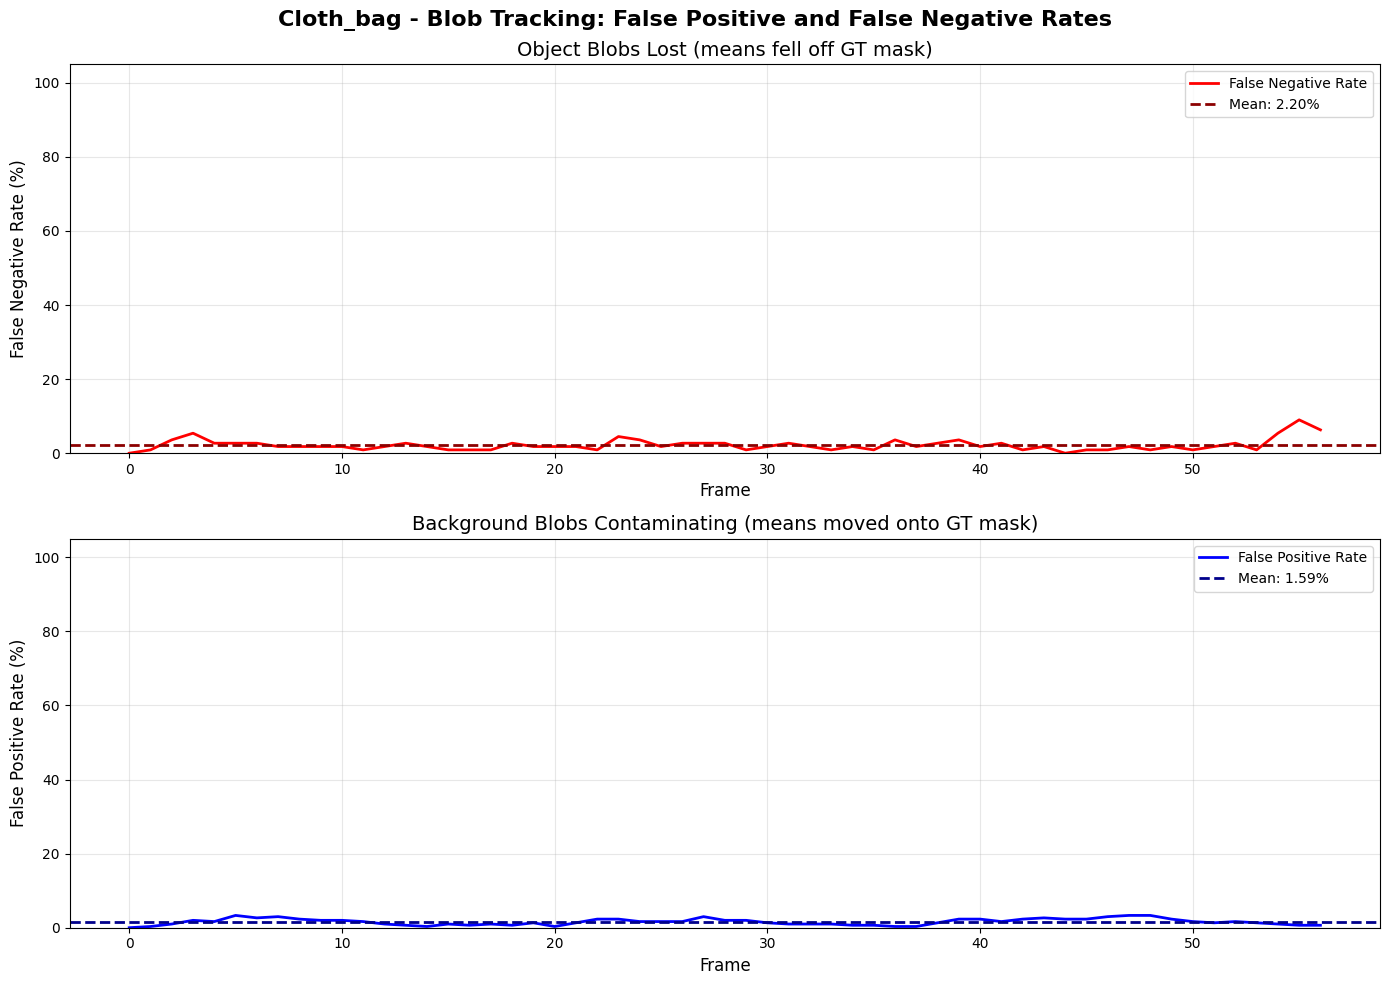

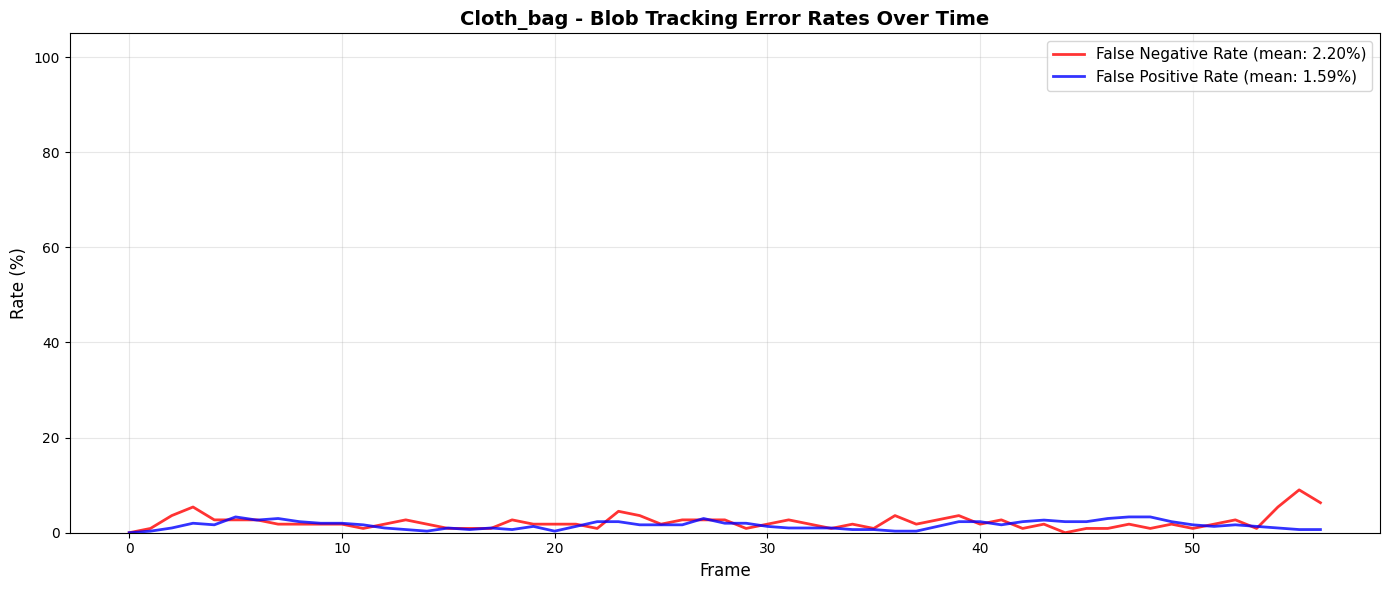


Evaluation complete!


In [23]:
# ============================================================================
# EVALUATION CONFIGURATION
# ============================================================================
BLOB_COUNTING_THRESHOLD = 100  # Minimum pixels for a blob to be counted in frame 0
                                # Only blobs with >= 100 assigned pixels in frame 0 are tracked

# Camera intrinsics for projection (using configuration from top of notebook)
fx = fy = FOCAL_LENGTH
cx = img_dims[1] / 2.0  # img_dims = (height, width)
cy = img_dims[0] / 2.0

# ============================================================================
# Compute False Positive and False Negative Rates
# ============================================================================
# This evaluation measures blob means projected to 2D:
# - TRUE POSITIVES: Object blobs (frame 0) whose means project onto GT mask
# - FALSE NEGATIVES: Object blobs (frame 0) whose means project off GT mask (lost)
# - FALSE POSITIVES: Background blobs (frame 0) whose means project onto GT mask (contamination)

stimulus = VIDEO_NAME
if stimulus in all_results:
    tracking_data = all_results[stimulus][0]  # First seed run
    
    print("="*80)
    print("BLOB TRACKING EVALUATION WITH FALSE POSITIVE/NEGATIVE RATES")
    print("="*80)
    print(f"Configuration:")
    print(f"  Video: {VIDEO_NAME}")
    print(f"  Object hyperblob: {HYPERBLOB_TO_SEGMENT}")
    print(f"  Blob counting threshold: {BLOB_COUNTING_THRESHOLD} pixels")
    print(f"  Total frames: {len(tracking_data)}")
    print()

    # Get ground truth segmentation masks for all frames
    from genparticles.evaluation import get_segmentation_mask

    segmentation_masks = []
    for frame_idx in range(len(tracking_data)):
        seg_mask = get_segmentation_mask(
            stimulus, frame_idx, DAVIS_SEGMASKS_PATH, img_dims=img_dims, flatten=True
        )
        segmentation_masks.append(seg_mask)

    print(f"Loaded {len(segmentation_masks)} ground truth segmentation masks\n")

    # ============================================================================
    # Step 1: Identify reference blobs in frame 0
    # ============================================================================
    frame0 = tracking_data[0]
    blob_assignments_frame0 = frame0['blob_assignments']
    hyperblob_assignments_frame0 = frame0['hyperblob_assignments']
    blob_means_frame0 = frame0['blob_means']
    n_blobs_frame0 = frame0['n_blobs']
    gt_mask_frame0 = segmentation_masks[0]

    # Count how many pixels each blob has in frame 0
    blob_pixel_counts_frame0 = np.bincount(
        blob_assignments_frame0[blob_assignments_frame0 < n_blobs_frame0],
        minlength=n_blobs_frame0
    )

    # Filter blobs: only keep those with >= BLOB_COUNTING_THRESHOLD pixels in frame 0
    significant_blobs = np.where(blob_pixel_counts_frame0 >= BLOB_COUNTING_THRESHOLD)[0]

    # Classify significant blobs as object or background based on hyperblob assignment
    object_blobs_frame0 = []
    background_blobs_frame0 = []

    for blob_idx in significant_blobs:
        if hyperblob_assignments_frame0[blob_idx] == HYPERBLOB_TO_SEGMENT:
            object_blobs_frame0.append(blob_idx)
        else:
            background_blobs_frame0.append(blob_idx)

    object_blobs_frame0 = np.array(object_blobs_frame0)
    background_blobs_frame0 = np.array(background_blobs_frame0)

    print(f"Frame 0 blob classification (threshold={BLOB_COUNTING_THRESHOLD} pixels):")
    print(f"  Total significant blobs (particles): {len(significant_blobs)}")
    print(f"  Object blobs (hyperblob {HYPERBLOB_TO_SEGMENT}): {len(object_blobs_frame0)}")
    print(f"  Background blobs (other hyperblobs): {len(background_blobs_frame0)}")
    print()

    # Verify object blobs by projecting their means to GT mask
    # Project blob means to 2D pixel coordinates
    x_2d = (blob_means_frame0[:, 0] / (blob_means_frame0[:, 2] + 1e-8)) * fx + cx
    y_2d = (blob_means_frame0[:, 1] / (blob_means_frame0[:, 2] + 1e-8)) * fy + cy
    x_2d = np.clip(x_2d.astype(int), 0, img_dims[1] - 1)
    y_2d = np.clip(y_2d.astype(int), 0, img_dims[0] - 1)
    pixel_indices_frame0 = y_2d * img_dims[1] + x_2d

    # Check which object blobs have means on GT mask
    object_blobs_on_mask = []
    for blob_idx in object_blobs_frame0:
        pixel_idx = pixel_indices_frame0[blob_idx]
        if pixel_idx < len(gt_mask_frame0) and gt_mask_frame0[pixel_idx]:
            object_blobs_on_mask.append(blob_idx)

    # Check which background blobs have means off GT mask
    background_blobs_off_mask = []
    for blob_idx in background_blobs_frame0:
        pixel_idx = pixel_indices_frame0[blob_idx]
        if pixel_idx >= len(gt_mask_frame0) or not gt_mask_frame0[pixel_idx]:
            background_blobs_off_mask.append(blob_idx)

    object_blobs_on_mask = np.array(object_blobs_on_mask)
    background_blobs_off_mask = np.array(background_blobs_off_mask)

    n_object_blobs = len(object_blobs_on_mask)
    n_background_blobs = len(background_blobs_off_mask)

    print(f"Reference blobs for tracking (verified against GT mask in frame 0):")
    print(f"  Object blobs with means ON GT mask: {n_object_blobs}")
    print(f"  Background blobs with means OFF GT mask: {n_background_blobs}")
    print()

    # ============================================================================
    # Step 2: Track blob means over time
    # ============================================================================
    # For each frame, project blob means and check if they're on/off GT mask

    false_negative_rates = []  # Object blobs that fell off GT mask
    false_positive_rates = []  # Background blobs that moved onto GT mask
    true_positive_counts = []  # Object blobs still on GT mask
    false_negative_counts = []  # Object blobs lost
    false_positive_counts = []  # Background blobs contaminating

    for frame_idx in range(len(tracking_data)):
        frame = tracking_data[frame_idx]
        blob_means = frame['blob_means']
        n_blobs = frame['n_blobs']
        gt_mask = segmentation_masks[frame_idx]
        
        # Project blob means to 2D
        x_2d = (blob_means[:, 0] / (blob_means[:, 2] + 1e-8)) * fx + cx
        y_2d = (blob_means[:, 1] / (blob_means[:, 2] + 1e-8)) * fy + cy
        x_2d = np.clip(x_2d.astype(int), 0, img_dims[1] - 1)
        y_2d = np.clip(y_2d.astype(int), 0, img_dims[0] - 1)
        pixel_indices = y_2d * img_dims[1] + x_2d
        
        # Check object blobs: how many still have means on GT mask?
        tp_count = 0
        for blob_idx in object_blobs_on_mask:
            if blob_idx < n_blobs:  # Blob still exists
                pixel_idx = pixel_indices[blob_idx]
                if pixel_idx < len(gt_mask) and gt_mask[pixel_idx]:
                    tp_count += 1
        
        # FALSE NEGATIVES: Object blobs that fell off GT mask
        fn_count = n_object_blobs - tp_count
        fn_rate = (fn_count / n_object_blobs) * 100 if n_object_blobs > 0 else 0.0
        
        # Check background blobs: how many now have means on GT mask?
        fp_count = 0
        for blob_idx in background_blobs_off_mask:
            if blob_idx < n_blobs:  # Blob still exists
                pixel_idx = pixel_indices[blob_idx]
                if pixel_idx < len(gt_mask) and gt_mask[pixel_idx]:
                    fp_count += 1
        
        # FALSE POSITIVES: Background blobs that moved onto GT mask
        fp_rate = (fp_count / n_background_blobs) * 100 if n_background_blobs > 0 else 0.0
        
        false_negative_rates.append(fn_rate)
        false_positive_rates.append(fp_rate)
        true_positive_counts.append(tp_count)
        false_negative_counts.append(fn_count)
        false_positive_counts.append(fp_count)

    # ============================================================================
    # Step 3: Summary statistics
    # ============================================================================
    mean_fn_rate = np.mean(false_negative_rates)
    mean_fp_rate = np.mean(false_positive_rates)
    mean_tp = np.mean(true_positive_counts)
    mean_fn = np.mean(false_negative_counts)
    mean_fp = np.mean(false_positive_counts)

    print("="*80)
    print("RESULTS")
    print("="*80)
    print(f"Mean False Negative Rate: {mean_fn_rate:.2f}%")
    print(f"  (Object blobs whose means fell off GT mask)")
    print(f"  Average lost: {mean_fn:.1f} / {n_object_blobs} blobs")
    print()
    print(f"Mean False Positive Rate: {mean_fp_rate:.2f}%")
    print(f"  (Background blobs whose means moved onto GT mask)")
    print(f"  Average contamination: {mean_fp:.1f} / {n_background_blobs} blobs")
    print()
    print(f"Mean True Positive Count: {mean_tp:.1f} / {n_object_blobs} blobs")
    print(f"  (Object blobs retained on GT mask)")
    print()
    print(f"Interpretation:")
    print(f"  - Lower FN rate = Better object blob retention")
    print(f"  - Lower FP rate = Less background blob contamination")
    print(f"  - Perfect tracking: FN=0%, FP=0%")
    print(f"  - Only blobs with ≥{BLOB_COUNTING_THRESHOLD} pixels in frame 0 are tracked")
    print("="*80)

    # Show per-frame breakdown (every 10 frames)
    print(f"\nPer-frame breakdown (every 10 frames):")
    print(f"{'Frame':<8} {'TP':<8} {'FN':<8} {'FP':<8} {'FN Rate (%)':<15} {'FP Rate (%)':<15}")
    print("-" * 70)
    for i in range(0, len(false_negative_rates), 10):
        print(f"{i:<8} {true_positive_counts[i]:<8} {false_negative_counts[i]:<8} {false_positive_counts[i]:<8} "
              f"{false_negative_rates[i]:<15.2f} {false_positive_rates[i]:<15.2f}")

    # ============================================================================
    # Step 4: Visualizations
    # ============================================================================
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    fig.suptitle(f'{VIDEO_NAME.capitalize()} - Blob Tracking: False Positive and False Negative Rates', 
                 fontsize=16, fontweight='bold')

    # Plot False Negative Rate
    axes[0].plot(range(len(false_negative_rates)), false_negative_rates, 
                 linewidth=2, color='red', label='False Negative Rate')
    axes[0].axhline(y=mean_fn_rate, color='darkred', linestyle='--', linewidth=2, 
                    label=f'Mean: {mean_fn_rate:.2f}%')
    axes[0].set_xlabel('Frame', fontsize=12)
    axes[0].set_ylabel('False Negative Rate (%)', fontsize=12)
    axes[0].set_title('Object Blobs Lost (means fell off GT mask)', fontsize=14)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(fontsize=10)
    axes[0].set_ylim([0, 105])

    # Plot False Positive Rate
    axes[1].plot(range(len(false_positive_rates)), false_positive_rates, 
                 linewidth=2, color='blue', label='False Positive Rate')
    axes[1].axhline(y=mean_fp_rate, color='darkblue', linestyle='--', linewidth=2, 
                    label=f'Mean: {mean_fp_rate:.2f}%')
    axes[1].set_xlabel('Frame', fontsize=12)
    axes[1].set_ylabel('False Positive Rate (%)', fontsize=12)
    axes[1].set_title('Background Blobs Contaminating (means moved onto GT mask)', fontsize=14)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(fontsize=10)
    axes[1].set_ylim([0, 105])

    plt.tight_layout()
    plt.show()

    # Combined plot
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(range(len(false_negative_rates)), false_negative_rates, 
            linewidth=2, color='red', label=f'False Negative Rate (mean: {mean_fn_rate:.2f}%)', alpha=0.8)
    ax.plot(range(len(false_positive_rates)), false_positive_rates, 
            linewidth=2, color='blue', label=f'False Positive Rate (mean: {mean_fp_rate:.2f}%)', alpha=0.8)
    ax.set_xlabel('Frame', fontsize=12)
    ax.set_ylabel('Rate (%)', fontsize=12)
    ax.set_title(f'{VIDEO_NAME.capitalize()} - Blob Tracking Error Rates Over Time', 
                 fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)
    ax.set_ylim([0, 105])
    plt.tight_layout()
    plt.show()

    print("\n" + "="*80)
    print(f"Evaluation complete!")
    print("="*80)
    
else:
    print(f"No results found for {stimulus}")

## Create 3-Wide Synchronized Video


In [24]:
# Create a 3-wide synchronized video (downscaled by 0.5x to reduce file size):
# 1. Original RGB frame
# 2. Inferred segmentation (object hyperblob = white, background = black)
# 3. Filtered blob assignments (only object hyperblob blobs colored, rest gray)

import cv2
import os
from glob import glob
import imageio
from tqdm import tqdm

print("Creating 3-wide synchronized video...")

# Load original RGB frames (1-indexed in DAVIS dataset)
rgb_dir = os.path.join(DAVIS_RGB_PATH, VIDEO_NAME)

# Find all RGB frames (typically named 00000.jpg, 00001.jpg, etc.)
rgb_files = sorted(glob(os.path.join(rgb_dir, "*.jpg")))

print(f"Found {len(rgb_files)} RGB frames in {rgb_dir}")
print(f"First file: {os.path.basename(rgb_files[0])}")
print(f"Last file: {os.path.basename(rgb_files[-1])}")

num_frames = len(tracking_data)
print(f"Number of tracking frames: {num_frames}")

# Prepare output
output_path = f"{VIDEO_NAME}_3wide_synchronized.mp4"

# Color map for blob assignments (unique colors per blob)
np.random.seed(42)
blob_colors = np.random.randint(0, 255, size=(NUM_BLOBS, 3), dtype=np.uint8)

combined_frames = []

for frame_idx in tqdm(range(num_frames), desc="Creating 3-wide video"):
    # 1. Load original RGB frame (1-indexed)
    rgb_frame = cv2.imread(rgb_files[frame_idx])
    rgb_frame = cv2.cvtColor(rgb_frame, cv2.COLOR_BGR2RGB)
    
    # Get tracking data
    frame = tracking_data[frame_idx]
    blob_assignments = frame['blob_assignments']
    hyperblob_assignments = frame['hyperblob_assignments']
    n_blobs = frame['n_blobs']
    
    # 2. Create inferred segmentation (hyperblob 0 = white, others = black)
    valid_mask = blob_assignments < n_blobs
    datapoint_hyperblob_assignments = np.full(len(blob_assignments), -1, dtype=int)
    datapoint_hyperblob_assignments[valid_mask] = hyperblob_assignments[blob_assignments[valid_mask]]
    
    binary_mask = np.where(datapoint_hyperblob_assignments == HYPERBLOB_TO_SEGMENT, 255, 0).astype(np.uint8)
    binary_image = binary_mask.reshape(img_height, img_width)
    segmentation_frame = np.stack([binary_image, binary_image, binary_image], axis=-1)
    
    # 3. Create FILTERED blob assignment visualization
    # Only show blob assignments for object hyperblob, everything else is gray
    background_color = np.array([128, 128, 128], dtype=np.uint8)
    object_blob_mask = np.zeros(len(blob_assignments), dtype=bool)
    for i in range(len(blob_assignments)):
        if valid_mask[i]:
            blob_idx = blob_assignments[i]
            if hyperblob_assignments[blob_idx] == HYPERBLOB_TO_SEGMENT:
                object_blob_mask[i] = True
    
    # Create colored visualization - only object blobs get unique colors
    blob_assignment_frame = np.zeros((len(blob_assignments), 3), dtype=np.uint8)
    blob_assignment_frame[~object_blob_mask] = background_color
    blob_assignment_frame[object_blob_mask] = blob_colors[blob_assignments[object_blob_mask]]
    blob_assignment_frame = blob_assignment_frame.reshape(img_height, img_width, 3)
    
    # Resize all frames to match dimensions (DAVIS frames might be different size)
    rgb_h, rgb_w = rgb_frame.shape[:2]
    if (rgb_h, rgb_w) != (img_height, img_width):
        segmentation_frame = cv2.resize(segmentation_frame, (rgb_w, rgb_h), interpolation=cv2.INTER_NEAREST)
        blob_assignment_frame = cv2.resize(blob_assignment_frame, (rgb_w, rgb_h), interpolation=cv2.INTER_NEAREST)
    else:
        rgb_h, rgb_w = img_height, img_width
    
    # Downscale frames to reduce video size
    SCALE_FACTOR = 0.5
    target_w = int(rgb_w * SCALE_FACTOR)
    target_h = int(rgb_h * SCALE_FACTOR)
    rgb_frame = cv2.resize(rgb_frame, (target_w, target_h), interpolation=cv2.INTER_AREA)
    segmentation_frame = cv2.resize(segmentation_frame, (target_w, target_h), interpolation=cv2.INTER_NEAREST)
    blob_assignment_frame = cv2.resize(blob_assignment_frame, (target_w, target_h), interpolation=cv2.INTER_NEAREST)
    
    # Add text labels
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.5
    font_thickness = 1
    text_color = (255, 255, 255)
    bg_color = (0, 0, 0)
    
    def add_label(img, text):
        img = img.copy()
        (text_width, text_height), baseline = cv2.getTextSize(text, font, font_scale, font_thickness)
        cv2.rectangle(img, (3, 3), (10 + text_width, 10 + text_height + baseline), bg_color, -1)
        cv2.putText(img, text, (5, 5 + text_height), font, font_scale, text_color, font_thickness)
        return img
    
    rgb_frame = add_label(rgb_frame, f"Original (Frame {frame_idx})")
    segmentation_frame = add_label(segmentation_frame, f"Segmentation")
    blob_assignment_frame = add_label(blob_assignment_frame, f"Particle Assignments")
    
    # Combine horizontally
    combined_frame = np.concatenate([rgb_frame, segmentation_frame, blob_assignment_frame], axis=1)
    combined_frames.append(combined_frame)

# Write video
print(f"Writing video with {len(combined_frames)} frames...")
imageio.mimsave(output_path, combined_frames, fps=30, codec='libx264', quality=7)

print(f"\n3-wide synchronized video saved to: {output_path}")
print(f"Resolution: {combined_frames[0].shape[1]}x{combined_frames[0].shape[0]}")
print(f"Frames: {len(combined_frames)}")
print(f"FPS: 30")


Creating 3-wide synchronized video...
Found 58 RGB frames in /home/esli/GenParticles_neural_stimulus/assets/cvpr_deformable_experiment/frames/cloth_bag
First file: 00000.jpg
Last file: 00057.jpg
Number of tracking frames: 57


Creating 3-wide video:   0%|          | 0/57 [00:00<?, ?it/s]

Creating 3-wide video: 100%|██████████| 57/57 [00:57<00:00,  1.00s/it]
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (5760, 1080) to (5760, 1088) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Writing video with 57 frames...

3-wide synchronized video saved to: cloth_bag_3wide_synchronized.mp4
Resolution: 5760x1080
Frames: 57
FPS: 30
